In [ ]:
import pandas as pd

df = pd.read_csv('/content/Unemployment in India.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove rows where important data is missing
df = df.dropna().copy()

# Convert Date column to proper date format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Remove extra spaces from text columns
df['Region'] = df['Region'].str.strip()
df['Frequency'] = df['Frequency'].str.strip()
df['Area'] = df['Area'].str.strip()

# Sort data by date
df = df.sort_values('Date').reset_index(drop=True)

print("\nData types:")
print(df.dtypes)

print("\nDataset shape after cleaning:", df.shape)

Missing values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Data types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Dataset shape after cleaning: (740, 7)


In [ ]:
# Create a COVID period column

df['Period'] = df['Date'].apply(
    lambda x: 'Pre-COVID' if x < pd.Timestamp('2020-03-01')
        else 'COVID'
        )

        # Check the number of records in each period
print(df['Period'].value_counts())

        # Calculate average unemployment rate for each period
period_summary = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()

print("\nAverage Unemployment Rate:")
print(period_summary)

Period
Pre-COVID    536
COVID        204
Name: count, dtype: int64

Average Unemployment Rate:
Period
COVID        17.774363
Pre-COVID     9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


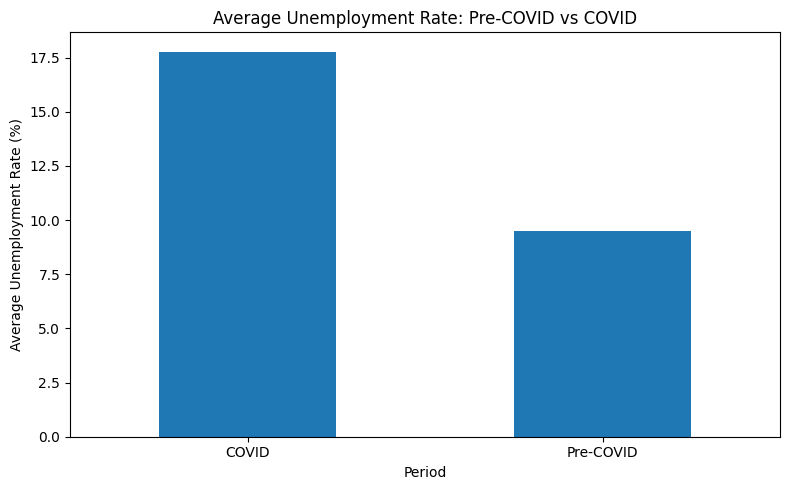

In [ ]:
import matplotlib.pyplot as plt

# Average unemployment rate by period
period_summary.plot(kind='bar', figsize=(8, 5))

plt.title('Average Unemployment Rate: Pre-COVID vs COVID')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Average unemployment rate by state/region

state_summary = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
state_summary = state_summary.sort_values(ascending=False)

print("Average Unemployment Rate by State/Region:")
print(state_summary)

Average Unemployment Rate by State/Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


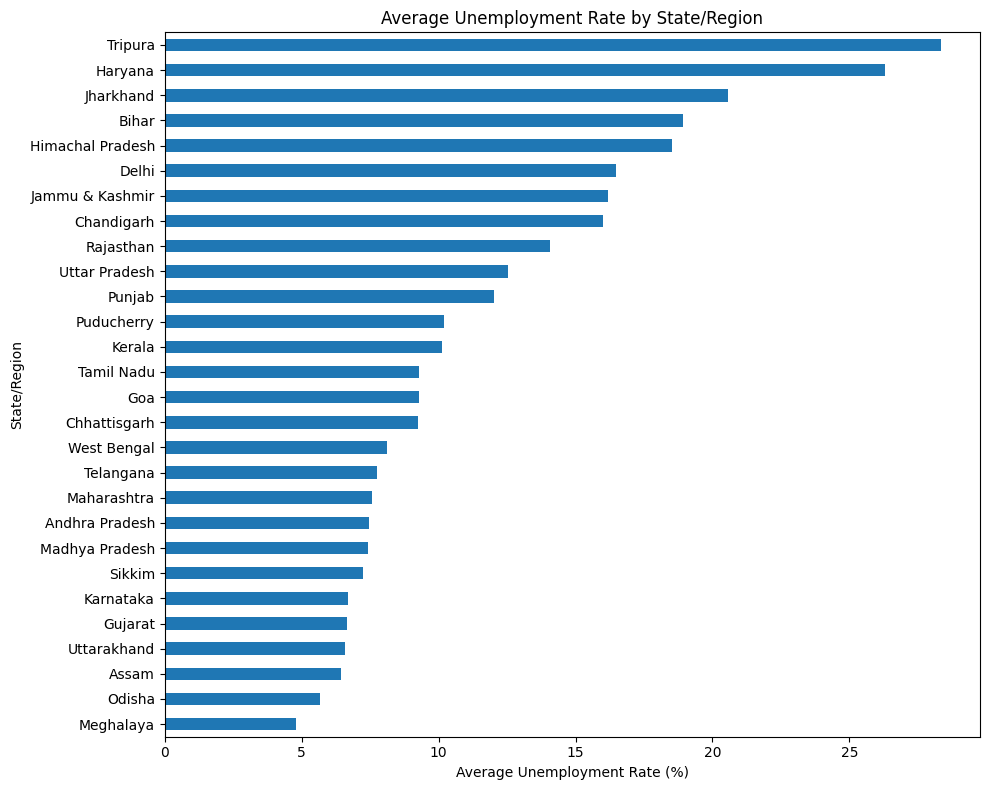

In [ ]:
# Plot average unemployment rate by state/region

plt.figure(figsize=(10, 8))

state_summary.sort_values().plot(kind='barh')

plt.title('Average Unemployment Rate by State/Region')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State/Region')
plt.tight_layout()
plt.show()

In [ ]:
# Create lag features for predictive modeling

df = df.sort_values(['Region', 'Date']).copy()

df['Lag_1'] = df.groupby('Region')['Estimated Unemployment Rate (%)'].shift(1)
df['Lag_2'] = df.groupby('Region')['Estimated Unemployment Rate (%)'].shift(2)
df['Lag_3'] = df.groupby('Region')['Estimated Unemployment Rate (%)'].shift(3)

# Remove rows where lag values are missing
df_model = df.dropna(subset=['Lag_1', 'Lag_2', 'Lag_3']).copy()

print("Original dataset shape:", df.shape)
print("Model dataset shape:", df_model.shape)

print("\nSample of lag features:")
print(df_model[['Region', 'Date',
                'Estimated Unemployment Rate (%)',
                                'Lag_1', 'Lag_2', 'Lag_3']].head(10))

Original dataset shape: (740, 11)
Model dataset shape: (656, 11)

Sample of lag features:
             Region       Date  Estimated Unemployment Rate (%)  Lag_1  Lag_2  \
102  Andhra Pradesh 2019-06-30                             3.05   3.80   6.09   
114  Andhra Pradesh 2019-07-31                             3.75   3.05   3.80   
136  Andhra Pradesh 2019-07-31                             5.64   3.75   3.05   
167  Andhra Pradesh 2019-08-31                             4.61   5.64   3.75   
188  Andhra Pradesh 2019-08-31                             3.32   4.61   5.64   
225  Andhra Pradesh 2019-09-30                             5.17   3.32   4.61   
235  Andhra Pradesh 2019-09-30                             6.01   5.17   3.32   
294  Andhra Pradesh 2019-10-31                             4.70   6.01   5.17   
312  Andhra Pradesh 2019-10-31                             3.52   4.70   6.01   
333  Andhra Pradesh 2019-11-30                             7.54   3.52   4.70   

     Lag_3  
102  

In [ ]:
# Prepare data for predictive modeling

# Select features
features = [
    'Estimated Employed',
        'Estimated Labour Participation Rate (%)',
            'Lag_1',
                'Lag_2',
                    'Lag_3'
                    ]

target = 'Estimated Unemployment Rate (%)'

X = df_model[features]
y = df_model[target]

                 # Time-based train-test split
split_index = int(len(df_model) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (524, 5)
Testing data: (132, 5)
Training target: (524,)
Testing target: (132,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Linear Regression model
model_lr = LinearRegression()

# Train the model
model_lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²  :", round(r2_lr, 3))

Linear Regression Performance
--------------------------------
MAE : 5.489
RMSE: 7.766
R²  : 0.497


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
model_rf = RandomForestRegressor(
    n_estimators=100,
        random_state=42
        )


       # Train the model
model_rf.fit(X_train, y_train)

        # Make predictions
y_pred_rf = model_rf.predict(X_test)

        # Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print("MAE :", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("R²  :", round(r2_rf, 3))

Random Forest Performance
--------------------------------
MAE : 4.509
RMSE: 7.055
R²  : 0.585


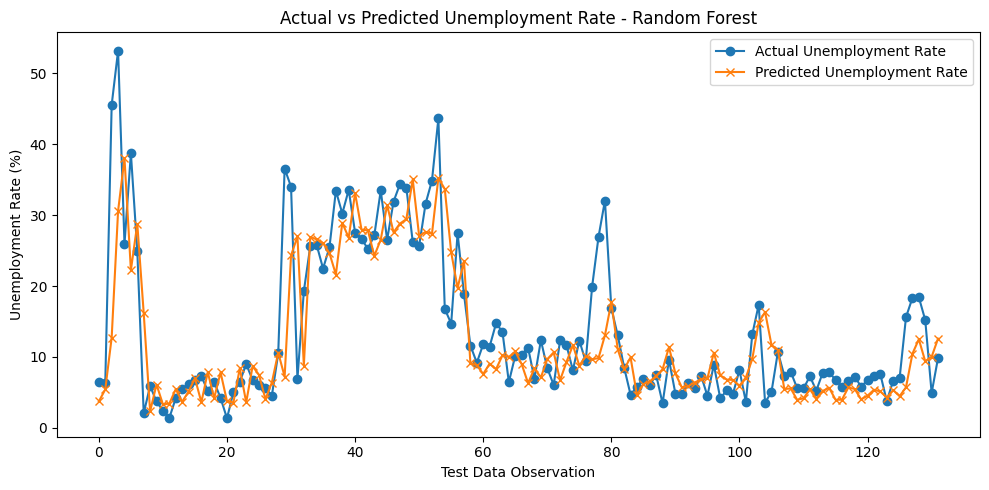

In [ ]:
# Actual vs Predicted Unemployment Rate

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
        label='Actual Unemployment Rate',
            marker='o'
            )

plt.plot(
               y_pred_rf,
                    label='Predicted Unemployment Rate',
                        marker='x'
                        )

plt.title('Actual vs Predicted Unemployment Rate - Random Forest')
plt.xlabel('Test Data Observation')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Feature importance from Random Forest

feature_importance = pd.Series(
    model_rf.feature_importances_,
        index=features
        ).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
Lag_1                                      0.399450
Estimated Employed                         0.224414
Lag_2                                      0.172727
Lag_3                                      0.108689
Estimated Labour Participation Rate (%)    0.094720
dtype: float64


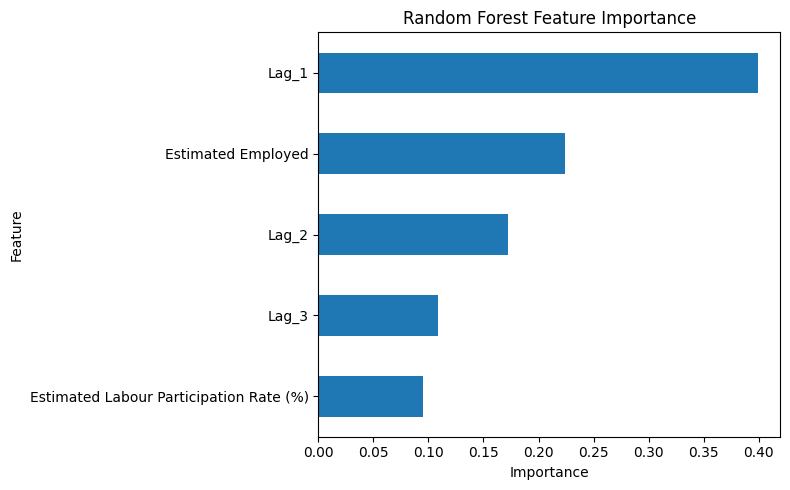

In [22]:
# Plot feature importance

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [23]:
# Compare model performance

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
        'MAE': [mae_lr, mae_rf],
            'RMSE': [rmse_lr, rmse_rf],
                'R2 Score': [r2_lr, r2_rf]
                })

print(results.round(3))

               Model    MAE   RMSE  R2 Score
0  Linear Regression  5.489  7.766     0.497
1      Random Forest  4.509  7.055     0.585


In [25]:
# Create corrected lag features separately for each Region and Area

df = df.sort_values(['Region', 'Area', 'Date']).copy()

df['Lag_1'] = df.groupby(['Region', 'Area'])[
    'Estimated Unemployment Rate (%)'
    ].shift(1)

df['Lag_2'] = df.groupby(['Region', 'Area'])[
        'Estimated Unemployment Rate (%)'
        ].shift(2)

df['Lag_3'] = df.groupby(['Region', 'Area'])[
            'Estimated Unemployment Rate (%)'
            ].shift(3)

            # Remove rows where lag values are missing
df_model = df.dropna(
                subset=['Lag_1', 'Lag_2', 'Lag_3']
                ).copy()

print("Corrected model dataset shape:", df_model.shape)
y
print("\nSample:")
print(df_model[
                    ['Region', 'Area', 'Date',
                         'Estimated Unemployment Rate (%)',
                              'Lag_1', 'Lag_2', 'Lag_3']
                              ].head(10))

Corrected model dataset shape: (575, 11)

Sample:
             Region   Area       Date  Estimated Unemployment Rate (%)  Lag_1  \
188  Andhra Pradesh  Rural 2019-08-31                             3.32   3.75   
225  Andhra Pradesh  Rural 2019-09-30                             5.17   3.32   
312  Andhra Pradesh  Rural 2019-10-31                             3.52   5.17   
375  Andhra Pradesh  Rural 2019-11-30                             4.12   3.52   
379  Andhra Pradesh  Rural 2019-12-31                             4.38   4.12   
440  Andhra Pradesh  Rural 2020-01-31                             4.84   4.38   
534  Andhra Pradesh  Rural 2020-02-29                             5.91   4.84   
580  Andhra Pradesh  Rural 2020-03-31                             4.06   5.91   
616  Andhra Pradesh  Rural 2020-04-30                            16.29   4.06   
666  Andhra Pradesh  Rural 2020-05-31                            14.46  16.29   

     Lag_2  Lag_3  
188   3.05   3.65  
225   3.75   3.05 

In [26]:
# Prepare corrected data for predictive modeling

features = [
    'Estimated Employed',
        'Estimated Labour Participation Rate (%)',
            'Lag_1',
                'Lag_2',
                    'Lag_3'
                    ]

target = 'Estimated Unemployment Rate (%)'

X = df_model[features]
y = df_model[target]

                    # Time-based 80/20 split        split_index = int(len(df_model) * 0.80)               X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (524, 5)
Testing data: (51, 5)
Training target: (524,)
Testing target: (51,)


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Linear Regression model
model_lr = LinearRegression()

# Train the model
model_lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Corrected Linear Regression Performance")
print("----------------------------------------")
print("MAE :", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²  :", round(r2_lr, 3))

Corrected Linear Regression Performance
----------------------------------------
MAE : 5.24
RMSE: 6.198
R²  : -0.194


In [28]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
model_rf = RandomForestRegressor(
    n_estimators=100,
        random_state=42
        )

        # Train the model
model_rf.fit(X_train, y_train)

        # Make predictions
y_pred_rf = model_rf.predict(X_test)

        # Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Corrected Random Forest Performance")
print("-----------------------------------")
print("MAE :", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("R²  :", round(r2_rf, 3))

Corrected Random Forest Performance
-----------------------------------
MAE : 4.954
RMSE: 6.22
R²  : -0.203


In [29]:
# Final comparison of corrected models

results_corrected = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
        'MAE': [mae_lr, mae_rf],
            'RMSE': [rmse_lr, rmse_rf],
                'R2 Score': [r2_lr, r2_rf]
                })

print(results_corrected.round(3))

               Model    MAE   RMSE  R2 Score
0  Linear Regression  5.240  6.198    -0.194
1      Random Forest  4.954  6.220    -0.203


In [30]:
# Feature importance from the corrected Random Forest model

feature_importance = pd.Series(
    model_rf.feature_importances_,
        index=features
        ).sort_values(ascending=False)

print("Corrected Random Forest Feature Importance:")
print(feature_importance)

Corrected Random Forest Feature Importance:
Estimated Employed                         0.257538
Estimated Labour Participation Rate (%)    0.229536
Lag_1                                      0.185645
Lag_3                                      0.171945
Lag_2                                      0.155335
dtype: float64


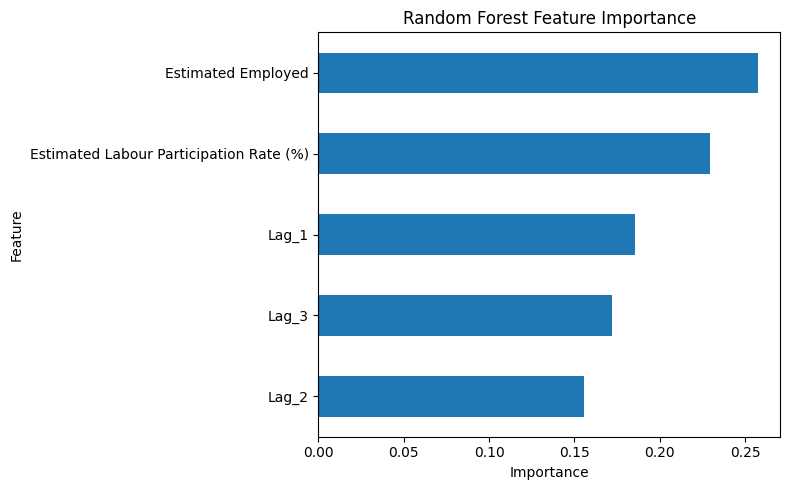

In [31]:
# Plot corrected Random Forest feature importance

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

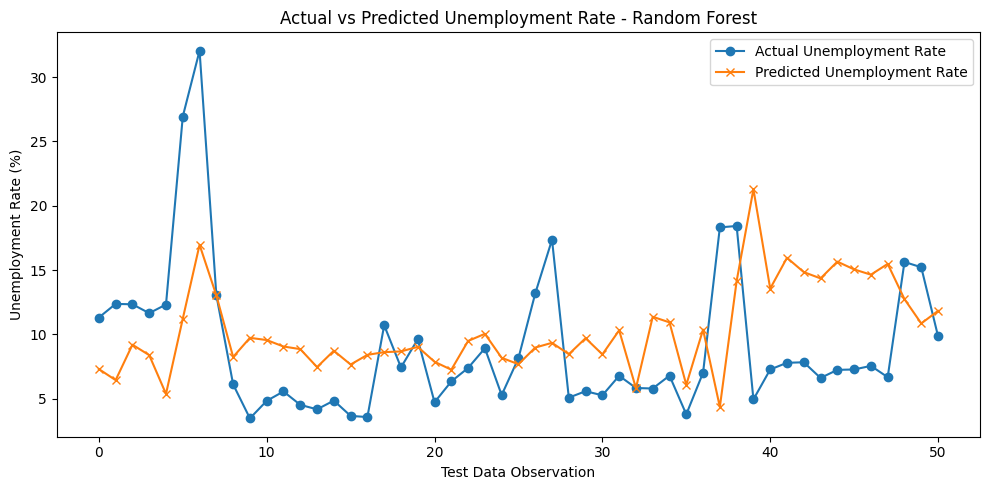

In [32]:
# Actual vs Predicted Unemployment Rate

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
        label='Actual Unemployment Rate',
            marker='o'
            )

plt.plot(
                y_pred_rf,
                    label='Predicted Unemployment Rate',
                        marker='x'
                        )

plt.title('Actual vs Predicted Unemployment Rate - Random Forest')
plt.xlabel('Test Data Observation')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Final Project Conclusion

print("FINAL CONCLUSION")
print("-----------------")

print("1. The average unemployment rate was higher during the COVID period")
print("   (17.77%) compared with the Pre-COVID period (9.51%).")

print("\n2. Predictive models were developed using historical unemployment")
print("   rates, employment, labour participation, and lag features.")

print("\n3. Linear Regression:")
print("   MAE =", round(mae_lr, 3))
print("   RMSE =", round(rmse_lr, 3))
print("   R2 =", round(r2_lr, 3))

print("\n4. Random Forest:")
print("   MAE =", round(mae_rf, 3))
print("   RMSE =", round(rmse_rf, 3))
print("   R2 =", round(r2_rf, 3))

print("\n5. Random Forest achieved a slightly lower MAE,")
print("   while Linear Regression achieved slightly better RMSE and R2.")

print("\n6. The most important Random Forest feature was")
print("   Estimated Employed, followed by Labour Participation Rate.")

print("\nOverall, the results show that historical and labour-market")
print("variables provide useful information for unemployment analysis,")
print("although the predictive models have limited generalization")
print("performance on the final test set.")

FINAL CONCLUSION
-----------------
1. The average unemployment rate was higher during the COVID period
   (17.77%) compared with the Pre-COVID period (9.51%).

2. Predictive models were developed using historical unemployment
   rates, employment, labour participation, and lag features.

3. Linear Regression:
   MAE = 5.24
   RMSE = 6.198
   R2 = -0.194

4. Random Forest:
   MAE = 4.954
   RMSE = 6.22
   R2 = -0.203

5. Random Forest achieved a slightly lower MAE,
   while Linear Regression achieved slightly better RMSE and R2.

6. The most important Random Forest feature was
   Estimated Employed, followed by Labour Participation Rate.

Overall, the results show that historical and labour-market
variables provide useful information for unemployment analysis,
although the predictive models have limited generalization
performance on the final test set.
